# Examen 3


Nombre: **Claudia Iriel Serrano Sánchez**

### Física Computacional 2026-2

Resuelva los siguientes ejercicios.

1. Genere una función que en el plano $xy$ se tenga una malla numérica de $N\times N$ con $x \in [0,1]$ y $y\in [0,1]$. En cada punto de la malla ponga un número aleatorio entre 0 y 1 si el punto pertenece al cuadrado y no pertence a un cículo con centro en cada uno de los vertices del cuadrado con radio 0.25. En el resto de los puntos ponga el número 0. Haga el dibujo de su función con la función imshow()

In [6]:
import numpy as np
import matplotlib.pyplot as plt

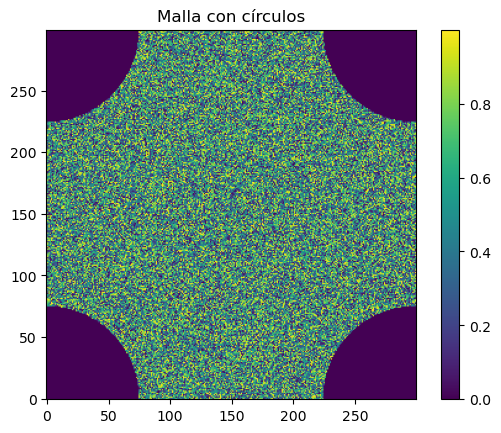

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def malla_con_circulos(N):
    
    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)

    X, Y = np.meshgrid(x,y)
    r = 0.25

    c1 = (X**2 + Y**2) < r**2
    c2 = ((X-1)**2 + Y**2) < r**2
    c3 = (X**2 + (Y-1)**2) < r**2
    c4 = ((X-1)**2 + (Y-1)**2) < r**2

    circulos = c1 | c2 | c3 | c4

    A = np.random.rand(N,N)

    A[circulos] = 0

    plt.imshow(A, origin='lower', cmap='viridis')
    plt.colorbar()
    plt.title("Malla con círculos")
    plt.show()

    return A


malla_con_circulos(300)

2. Genere una función que haga una matriz de $N\times N$ con la siguientes características:
   - En la diagonal principal debe tener el valor $1/N$
   - En la diagonal superior a la principal debe tener el valor $1/N^2$
   - En la diagonal inferior a la principal debe tener el valor $1/N^3$

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
import numpy as np

def matriz_diagonal(N):

    A = np.zeros((N,N))
    np.fill_diagonal(A,1/N)

    for i in range(N-1):
        A[i,i+1] = 1/N**2

    for i in range(N-1):
        A[i+1,i] = 1/N**3

    return A

In [17]:
N = 10
A = matriz_diagonal(N)

print(A)

[[0.1   0.01  0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.001 0.1   0.01  0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.001 0.1   0.01  0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.1   0.01  0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.001 0.1   0.01  0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.001 0.1   0.01  0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.001 0.1   0.01  0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.001 0.1   0.01  0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.001 0.1   0.01 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.001 0.1  ]]


3. Genere una función que reciba una matriz y que a la salida proporcione la matriz transpuesta, la inversa de una matriz y el cuadrado de dicha matriz ($A^2 = A A$)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def operaciones_con_matriz(A):

    AT = A.T
    Ainv = np.linalg.inv(A)
    A2 = A @ A

    return AT, Ainv, A2

In [27]:
A = np.array([[7,8],
              [9,10]])

AT, Ainv, A2 = operaciones_con_matriz(A)

print("Transpuesta:")
print(AT)

print("Inversa:")
print(Ainv)

print(r"A^2:")
print(A2)

Transpuesta:
[[ 7  9]
 [ 8 10]]
Inversa:
[[-5.   4. ]
 [ 4.5 -3.5]]
A^2:
[[121 136]
 [153 172]]


4. Genere la misma función que se solicita en el problema dos, pero utilice matrices espacidas debido a la gran cantidad de ceros.

In [28]:
import numpy as np
from scipy.sparse import diags

In [29]:
def matriz_sparse(N):
    diag0 = np.ones(N)*(1/N)

    diag1 = np.ones(N-1)*(1/N**2)

    diag_1 = np.ones(N-1)*(1/N**3)


    A = diags([diag_1,diag0,diag1],
              [-1,0,1],
              format='csr')

    return A

In [31]:

A = matriz_sparse(200)

print(A)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 598 stored elements and shape (200, 200)>
  Coords	Values
  (0, 0)	0.005
  (0, 1)	2.5e-05
  (1, 0)	1.25e-07
  (1, 1)	0.005
  (1, 2)	2.5e-05
  (2, 1)	1.25e-07
  (2, 2)	0.005
  (2, 3)	2.5e-05
  (3, 2)	1.25e-07
  (3, 3)	0.005
  (3, 4)	2.5e-05
  (4, 3)	1.25e-07
  (4, 4)	0.005
  (4, 5)	2.5e-05
  (5, 4)	1.25e-07
  (5, 5)	0.005
  (5, 6)	2.5e-05
  (6, 5)	1.25e-07
  (6, 6)	0.005
  (6, 7)	2.5e-05
  (7, 6)	1.25e-07
  (7, 7)	0.005
  (7, 8)	2.5e-05
  (8, 7)	1.25e-07
  (8, 8)	0.005
  :	:
  (191, 191)	0.005
  (191, 192)	2.5e-05
  (192, 191)	1.25e-07
  (192, 192)	0.005
  (192, 193)	2.5e-05
  (193, 192)	1.25e-07
  (193, 193)	0.005
  (193, 194)	2.5e-05
  (194, 193)	1.25e-07
  (194, 194)	0.005
  (194, 195)	2.5e-05
  (195, 194)	1.25e-07
  (195, 195)	0.005
  (195, 196)	2.5e-05
  (196, 195)	1.25e-07
  (196, 196)	0.005
  (196, 197)	2.5e-05
  (197, 196)	1.25e-07
  (197, 197)	0.005
  (197, 198)	2.5e-05
  (198, 197)	1.25e-07
  (198, 198)	0.005
  (198